# Contextual Multi-Arm Bandit: Model Comparison

This notebook implements a **Contextual Multi-Arm Bandit (CMAB)** following the analogy of a teacher offering different lesson types to students.

## Problem Setup

- **Context**: Each student has features (prior knowledge, study hours, aptitude)
- **Arms**: Different lesson types (visual, auditory, hands-on)
- **Reward**: Student's test score after the lesson
- **Goal**: Learn which lesson type works best for which type of student

The teacher doesn't know upfront which lesson type is best for each student type, so they must balance **exploration** (trying different lessons) with **exploitation** (using the best-known lesson type).

## Notebook Sections

1. **Problem Setup** - Ground truth and student generation
2. **Train XGBoost CMAB** - Batch learning approach
3. **Experiment with Different Epsilons** - Exploration vs exploitation trade-off
4. **Train Neural Network CMAB** - Online learning approach
5. **Compare Best Performing Models** - XGBoost vs Neural Network
6. **Conclusion** - Summary of findings

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Import our CMAB package
from cmab import (
    GroundTruthRewardFunction,
    generate_student_class,
    train_bandit,
    ContextualBanditXGB,
    ContextualBanditNN,
    CLASS_SIZE,
    TARGET_COUNTS,
)

# Set random seed for reproducibility
np.random.seed(42)
sns.set_style("whitegrid")

print("Libraries loaded successfully!")
print(f"Class size: {CLASS_SIZE} students per epoch")
print(f"Target distribution: {TARGET_COUNTS}")

Libraries loaded successfully!
Class size: 100 students per epoch
Target distribution: {0: 60, 1: 30, 2: 10}


## 1. Problem Setup

### Ground Truth Reward Function

The ground truth function represents the TRUE relationship between student features and lesson effectiveness. In reality, the teacher doesn't know this function - they must learn it through interaction.

**Student Features:**
- Prior knowledge (0-1)
- Study hours per week (0-1, normalized)  
- Mathematical aptitude (0-1)

**Lesson Types (Arms):**
- 0: Visual lessons (diagrams, videos) - benefits high aptitude students
- 1: Auditory lessons (lectures, discussions) - benefits those with prior knowledge
- 2: Hands-on lessons (projects, experiments) - benefits hard workers

In [2]:
# Initialize ground truth and test with example students
ground_truth = GroundTruthRewardFunction()

# Example student profiles
students = {
    "High Aptitude": np.array([0.5, 0.5, 0.9]),  # High math aptitude
    "Prior Knowledge": np.array([0.9, 0.5, 0.5]),  # High prior knowledge
    "Hard Worker": np.array([0.5, 0.9, 0.5])  # Studies a lot
}

lesson_types = {0: "Visual", 1: "Auditory", 2: "Hands-on"}

print("Average test scores for different student types and lesson types:\n")
for student_name, context in students.items():
    print(f"{student_name} Student:")
    for arm, lesson_name in lesson_types.items():
        # Average over multiple trials to reduce noise
        scores = [ground_truth.get_reward(context, arm) for _ in range(100)]
        avg_score = np.mean(scores)
        is_best = (arm == ground_truth.get_optimal_arm(context))
        marker = " ⭐ BEST" if is_best else ""
        print(f"  {lesson_name:12s}: {avg_score:.1f}{marker}")
    print()

Average test scores for different student types and lesson types:

High Aptitude Student:
  Visual      : 120.7 ⭐ BEST
  Auditory    : 72.7
  Hands-on    : 83.0

Prior Knowledge Student:
  Visual      : 85.8
  Auditory    : 120.2 ⭐ BEST
  Hands-on    : 78.5

Hard Worker Student:
  Visual      : 72.9
  Auditory    : 83.7
  Hands-on    : 115.4 ⭐ BEST



In [3]:
# Generate an example class to visualize the student population
student_class = generate_student_class(ground_truth, class_size=CLASS_SIZE, target_counts=TARGET_COUNTS)

print(f"Example class of {CLASS_SIZE} students:\n")
print(f"{'ID':<5} {'Prior':<8} {'Study':<8} {'Aptitude':<8} {'Optimal Lesson':<15}")
print("-" * 60)
for i in [0, 20, 40, 60, 80, 90]:
    s = student_class[i]
    lesson_name = lesson_types[s['optimal_arm']]
    print(f"{s['id']:<5} {s['context'][0]:<8.3f} {s['context'][1]:<8.3f} {s['context'][2]:<8.3f} {lesson_name:<15}")

# Show distribution of optimal lessons
optimal_counts = {0: 0, 1: 0, 2: 0}
for s in student_class:
    optimal_counts[s['optimal_arm']] += 1

print("\nClass composition by optimal lesson type:")
for arm, count in optimal_counts.items():
    print(f"  {lesson_types[arm]:12s}: {count:2d} students ({count/CLASS_SIZE*100:.1f}%)")

Example class of 100 students:

ID    Prior    Study    Aptitude Optimal Lesson 
------------------------------------------------------------
0     0.091    0.263    0.875    Visual         
20    0.468    0.071    0.598    Visual         
40    0.395    0.322    0.610    Visual         
60    0.864    0.473    0.968    Visual         
80    0.763    0.759    0.886    Hands-on       
90    0.909    0.370    0.751    Visual         

Class composition by optimal lesson type:
  Visual      : 60 students (60.0%)
  Auditory    : 30 students (30.0%)
  Hands-on    : 10 students (10.0%)


## 2. Train XGBoost CMAB

The XGBoost-based bandit uses **batch learning**: it retrains on all historical data after each new observation. This approach:
- ✅ Can capture complex non-linear relationships
- ✅ Works well with structured/tabular data
- ❌ Becomes slower as data accumulates (O(n²) complexity)
- ❌ Requires storing all historical data

In [4]:
# Train XGBoost bandit with epsilon = 0.1
print("=" * 60)
print("Training XGBoost Contextual Bandit (epsilon = 0.1)")
print("=" * 60)

xgb_bandit = ContextualBanditXGB(n_arms=3, n_features=3, epsilon=0.1)
xgb_history = train_bandit(
    xgb_bandit,
    ground_truth,
    class_size=CLASS_SIZE,
    target_counts=TARGET_COUNTS,
    n_epochs=20,
)

Training XGBoost Contextual Bandit (epsilon = 0.1)
Epoch  1/20: Accuracy =  70.0%, Avg Reward = 95.99, Regret = 972.97
Epoch  2/20: Accuracy =  83.0%, Avg Reward = 99.50, Regret = 1374.16
Epoch  3/20: Accuracy =  80.0%, Avg Reward = 100.30, Regret = 1911.00
Epoch  4/20: Accuracy =  80.0%, Avg Reward = 101.24, Regret = 2672.27
Epoch  5/20: Accuracy =  88.0%, Avg Reward = 101.85, Regret = 2994.76
Epoch  6/20: Accuracy =  86.0%, Avg Reward = 102.40, Regret = 3413.83
Epoch  7/20: Accuracy =  89.0%, Avg Reward = 102.75, Regret = 3683.38
Epoch  8/20: Accuracy =  93.0%, Avg Reward = 103.78, Regret = 3937.03
Epoch  9/20: Accuracy =  81.0%, Avg Reward = 103.65, Regret = 4417.63
Epoch 10/20: Accuracy =  82.0%, Avg Reward = 103.41, Regret = 4874.12
Epoch 11/20: Accuracy =  87.0%, Avg Reward = 103.46, Regret = 5198.44
Epoch 12/20: Accuracy =  89.0%, Avg Reward = 103.65, Regret = 5476.24
Epoch 13/20: Accuracy =  82.0%, Avg Reward = 103.51, Regret = 5901.49
Epoch 14/20: Accuracy =  87.0%, Avg Reward

## 3. Experiment with Different Epsilons (XGBoost)

The epsilon parameter controls the exploration-exploitation trade-off:
- **ε = 0**: Pure exploitation (always choose best known arm)
- **ε = 1**: Pure exploration (always choose randomly)

Higher epsilon leads to more exploration early on but sacrifices rewards. Lower epsilon exploits quickly but may miss the optimal arm if initial data is misleading.

In [5]:
# Compare different epsilon values for XGBoost
epsilon_values = [0.0, 0.05, 0.1, 0.2, 0.3]
xgb_results = {}

print("Training XGBoost bandits with different exploration rates...\n")

for eps in epsilon_values:
    print(f"Training with epsilon = {eps}")
    bandit = ContextualBanditXGB(n_arms=3, n_features=3, epsilon=eps)
    history = train_bandit(
        bandit,
        ground_truth,
        class_size=CLASS_SIZE,
        target_counts=TARGET_COUNTS,
        n_epochs=20,
        verbose=False,
    )
    xgb_results[eps] = history
    
    n_epochs = max(history['epoch']) + 1
    final_epoch_idx = (n_epochs - 1) * CLASS_SIZE
    final_accuracy = history['epoch_accuracy'][final_epoch_idx]
    print(f"  Final epoch accuracy: {final_accuracy:.1f}%")
    print(f"  Final regret: {history['regret'][-1]:.2f}\n")

# Find best epsilon for XGBoost
best_xgb_eps = min(xgb_results.keys(), key=lambda e: xgb_results[e]['regret'][-1])
print(f"Best epsilon for XGBoost: {best_xgb_eps} (lowest regret)")

Training XGBoost bandits with different exploration rates...

Training with epsilon = 0.0
  Final epoch accuracy: 86.0%
  Final regret: 6471.31

Training with epsilon = 0.05
  Final epoch accuracy: 87.0%
  Final regret: 6326.07

Training with epsilon = 0.1
  Final epoch accuracy: 87.0%
  Final regret: 8285.21

Training with epsilon = 0.2
  Final epoch accuracy: 82.0%
  Final regret: 14971.32

Training with epsilon = 0.3
  Final epoch accuracy: 71.0%
  Final regret: 20458.38

Best epsilon for XGBoost: 0.05 (lowest regret)


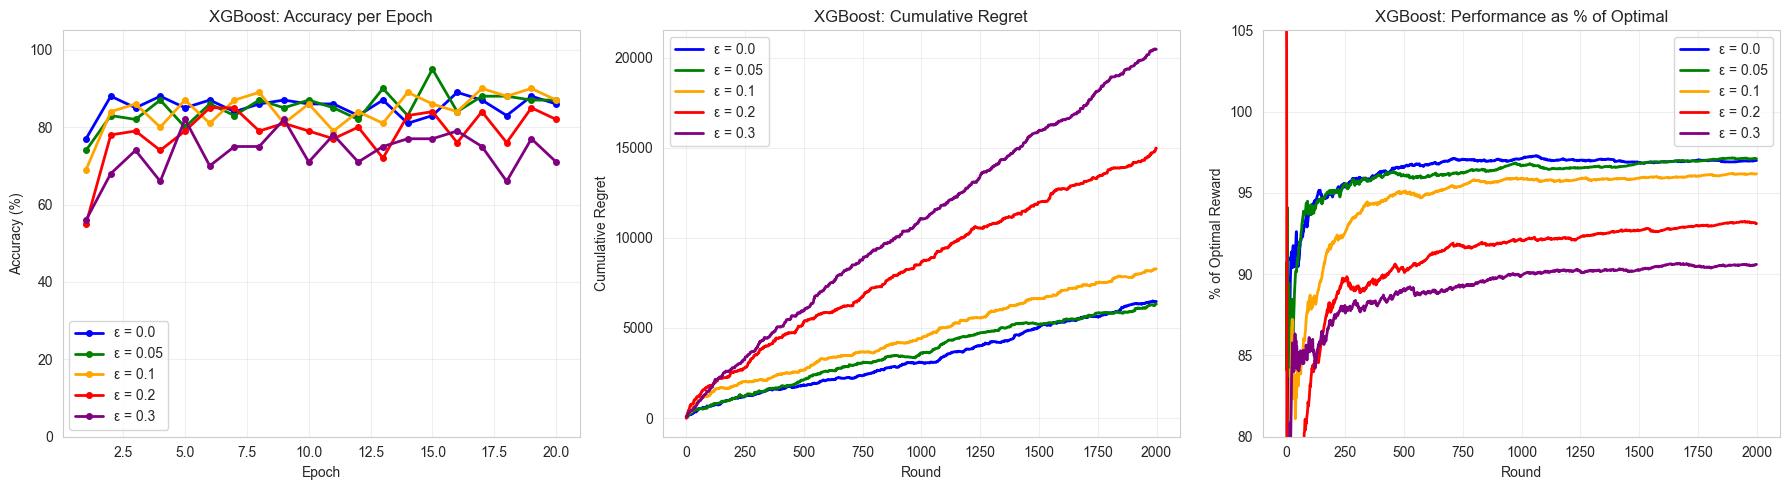


XGBoost Exploration Strategy Comparison
 Epsilon   | Final Accuracy  |  Final Regret   |  % of Optimal  
--------------------------------------------------------------------------------
   0.00    |      86.0       |     6471.31     |      96.99     
   0.05    |      87.0       |     6326.07     |      97.11      ⭐
   0.10    |      87.0       |     8285.21     |      96.17     
   0.20    |      82.0       |    14971.32     |      93.11     
   0.30    |      71.0       |    20458.38     |      90.60     


In [6]:
# Plot XGBoost epsilon comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['blue', 'green', 'orange', 'red', 'purple']

# Plot 1: Accuracy Learning Curves
for i, eps in enumerate(epsilon_values):
    n_epochs = max(xgb_results[eps]['epoch']) + 1
    epochs = list(range(1, n_epochs + 1))
    accuracies = [xgb_results[eps]['epoch_accuracy'][e * CLASS_SIZE] for e in range(n_epochs)]
    axes[0].plot(epochs, accuracies, label=f'ε = {eps}', linewidth=2, marker='o', markersize=4, color=colors[i])

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('XGBoost: Accuracy per Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 105])

# Plot 2: Cumulative Regret
for i, eps in enumerate(epsilon_values):
    axes[1].plot(xgb_results[eps]['round'], xgb_results[eps]['regret'], label=f'ε = {eps}', linewidth=2, color=colors[i])
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Cumulative Regret')
axes[1].set_title('XGBoost: Cumulative Regret')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: % of Optimal Reward
for i, eps in enumerate(epsilon_values):
    pct_optimal = [
        xgb_results[eps]['cumulative_reward'][j] / xgb_results[eps]['cumulative_optimal_reward'][j] * 100
        for j in range(len(xgb_results[eps]['round']))
    ]
    axes[2].plot(xgb_results[eps]['round'], pct_optimal, label=f'ε = {eps}', linewidth=2, color=colors[i])
axes[2].set_xlabel('Round')
axes[2].set_ylabel('% of Optimal Reward')
axes[2].set_title('XGBoost: Performance as % of Optimal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([80, 105])

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 80)
print("XGBoost Exploration Strategy Comparison")
print("=" * 80)
print(f"{'Epsilon':^10} | {'Final Accuracy':^15} | {'Final Regret':^15} | {'% of Optimal':^15}")
print("-" * 80)
for eps in epsilon_values:
    final_epoch_idx = (n_epochs - 1) * CLASS_SIZE
    final_accuracy = xgb_results[eps]['epoch_accuracy'][final_epoch_idx]
    final_regret = xgb_results[eps]['regret'][-1]
    pct_optimal = xgb_results[eps]['cumulative_reward'][-1] / xgb_results[eps]['cumulative_optimal_reward'][-1] * 100
    marker = " ⭐" if eps == best_xgb_eps else ""
    print(f"{eps:^10.2f} | {final_accuracy:^15.1f} | {final_regret:^15.2f} | {pct_optimal:^15.2f}{marker}")

## 4. Train Neural Network CMAB

The Neural Network-based bandit uses **online learning**: it updates incrementally with each new observation using gradient descent. This approach:
- ✅ Constant time updates (O(1) per observation)
- ✅ Fixed memory footprint (replay buffer)
- ✅ Can learn complex non-linear patterns
- ❌ May be less sample-efficient initially
- ❌ Requires tuning of learning rate and architecture

In [7]:
# Train Neural Network bandit with epsilon = 0.1
print("=" * 60)
print("Training Neural Network Contextual Bandit (epsilon = 0.1)")
print("=" * 60)

nn_bandit = ContextualBanditNN(
    n_arms=3, 
    n_features=3, 
    epsilon=0.1,
    learning_rate=0.01,
    hidden_sizes=[64, 32],
    replay_buffer_size=500,
    batch_size=32,
)

nn_history = train_bandit(
    nn_bandit,
    ground_truth,
    class_size=CLASS_SIZE,
    target_counts=TARGET_COUNTS,
    n_epochs=20,
)

Training Neural Network Contextual Bandit (epsilon = 0.1)
Epoch  1/20: Accuracy =  46.0%, Avg Reward = 87.25, Regret = 2405.90
Epoch  2/20: Accuracy =  78.0%, Avg Reward = 92.67, Regret = 3024.14
Epoch  3/20: Accuracy =  83.0%, Avg Reward = 96.36, Regret = 3433.27
Epoch  4/20: Accuracy =  75.0%, Avg Reward = 97.07, Regret = 4166.20
Epoch  5/20: Accuracy =  81.0%, Avg Reward = 98.34, Regret = 4485.28
Epoch  6/20: Accuracy =  76.0%, Avg Reward = 98.77, Regret = 4901.30
Epoch  7/20: Accuracy =  81.0%, Avg Reward = 99.59, Regret = 5408.92
Epoch  8/20: Accuracy =  87.0%, Avg Reward = 100.25, Regret = 5717.61
Epoch  9/20: Accuracy =  92.0%, Avg Reward = 100.63, Regret = 5874.07
Epoch 10/20: Accuracy =  90.0%, Avg Reward = 101.30, Regret = 6024.37
Epoch 11/20: Accuracy =  90.0%, Avg Reward = 101.87, Regret = 6248.96
Epoch 12/20: Accuracy =  89.0%, Avg Reward = 102.33, Regret = 6639.67
Epoch 13/20: Accuracy =  84.0%, Avg Reward = 102.69, Regret = 6861.23
Epoch 14/20: Accuracy =  90.0%, Avg Rew

In [8]:
# Compare different epsilon values for Neural Network
nn_results = {}

print("Training Neural Network bandits with different exploration rates...\n")

for eps in epsilon_values:
    print(f"Training with epsilon = {eps}")
    bandit = ContextualBanditNN(
        n_arms=3, 
        n_features=3, 
        epsilon=eps,
        learning_rate=0.01,
        hidden_sizes=[64, 32],
        replay_buffer_size=500,
        batch_size=32,
    )
    history = train_bandit(
        bandit,
        ground_truth,
        class_size=CLASS_SIZE,
        target_counts=TARGET_COUNTS,
        n_epochs=20,
        verbose=False,
    )
    nn_results[eps] = history
    
    n_epochs = max(history['epoch']) + 1
    final_epoch_idx = (n_epochs - 1) * CLASS_SIZE
    final_accuracy = history['epoch_accuracy'][final_epoch_idx]
    print(f"  Final epoch accuracy: {final_accuracy:.1f}%")
    print(f"  Final regret: {history['regret'][-1]:.2f}\n")

# Find best epsilon for Neural Network
best_nn_eps = min(nn_results.keys(), key=lambda e: nn_results[e]['regret'][-1])
print(f"Best epsilon for Neural Network: {best_nn_eps} (lowest regret)")

Training Neural Network bandits with different exploration rates...

Training with epsilon = 0.0
  Final epoch accuracy: 30.0%
  Final regret: 58311.06

Training with epsilon = 0.05
  Final epoch accuracy: 89.0%
  Final regret: 8556.12

Training with epsilon = 0.1
  Final epoch accuracy: 88.0%
  Final regret: 12195.77

Training with epsilon = 0.2
  Final epoch accuracy: 82.0%
  Final regret: 15425.63

Training with epsilon = 0.3
  Final epoch accuracy: 75.0%
  Final regret: 17379.31

Best epsilon for Neural Network: 0.05 (lowest regret)


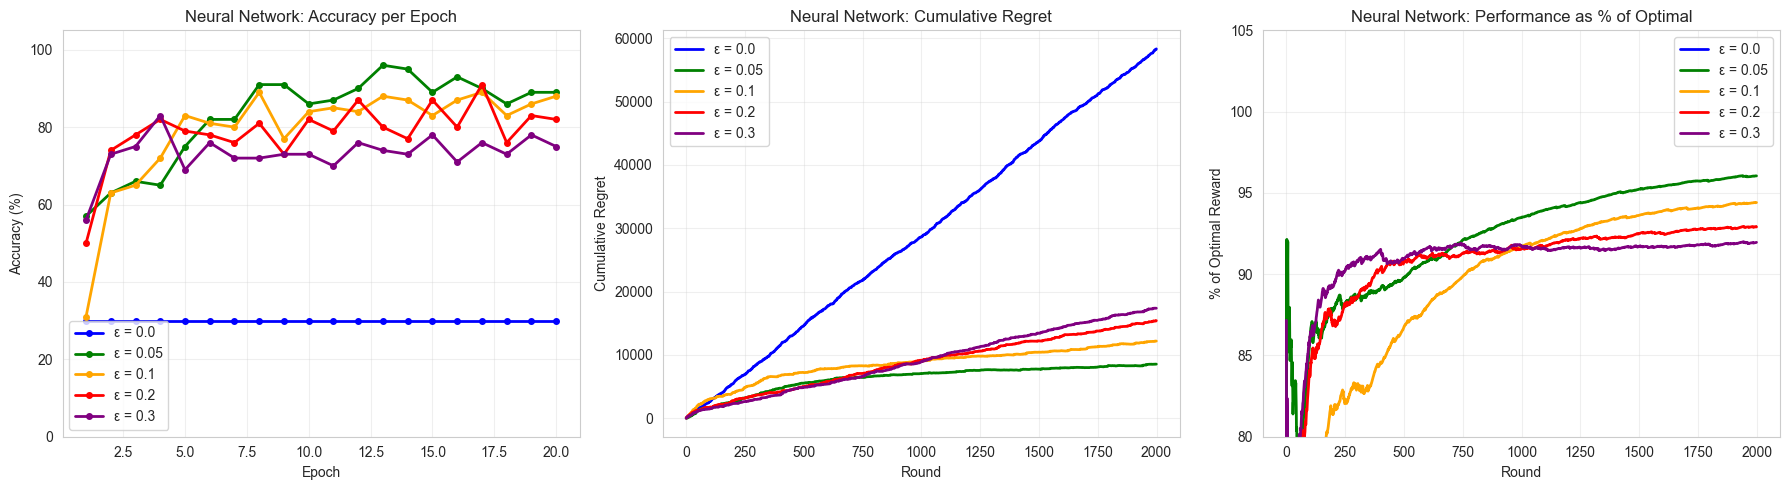


Neural Network Exploration Strategy Comparison
 Epsilon   | Final Accuracy  |  Final Regret   |  % of Optimal  
--------------------------------------------------------------------------------
   0.00    |      30.0       |    58311.06     |      73.15     
   0.05    |      89.0       |     8556.12     |      96.05      ⭐
   0.10    |      88.0       |    12195.77     |      94.41     
   0.20    |      82.0       |    15425.63     |      92.91     
   0.30    |      75.0       |    17379.31     |      91.96     


In [9]:
# Plot Neural Network epsilon comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Accuracy Learning Curves
for i, eps in enumerate(epsilon_values):
    n_epochs = max(nn_results[eps]['epoch']) + 1
    epochs = list(range(1, n_epochs + 1))
    accuracies = [nn_results[eps]['epoch_accuracy'][e * CLASS_SIZE] for e in range(n_epochs)]
    axes[0].plot(epochs, accuracies, label=f'ε = {eps}', linewidth=2, marker='o', markersize=4, color=colors[i])

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Neural Network: Accuracy per Epoch')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 105])

# Plot 2: Cumulative Regret
for i, eps in enumerate(epsilon_values):
    axes[1].plot(nn_results[eps]['round'], nn_results[eps]['regret'], label=f'ε = {eps}', linewidth=2, color=colors[i])
axes[1].set_xlabel('Round')
axes[1].set_ylabel('Cumulative Regret')
axes[1].set_title('Neural Network: Cumulative Regret')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: % of Optimal Reward
for i, eps in enumerate(epsilon_values):
    pct_optimal = [
        nn_results[eps]['cumulative_reward'][j] / nn_results[eps]['cumulative_optimal_reward'][j] * 100
        for j in range(len(nn_results[eps]['round']))
    ]
    axes[2].plot(nn_results[eps]['round'], pct_optimal, label=f'ε = {eps}', linewidth=2, color=colors[i])
axes[2].set_xlabel('Round')
axes[2].set_ylabel('% of Optimal Reward')
axes[2].set_title('Neural Network: Performance as % of Optimal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([80, 105])

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "=" * 80)
print("Neural Network Exploration Strategy Comparison")
print("=" * 80)
print(f"{'Epsilon':^10} | {'Final Accuracy':^15} | {'Final Regret':^15} | {'% of Optimal':^15}")
print("-" * 80)
for eps in epsilon_values:
    final_epoch_idx = (n_epochs - 1) * CLASS_SIZE
    final_accuracy = nn_results[eps]['epoch_accuracy'][final_epoch_idx]
    final_regret = nn_results[eps]['regret'][-1]
    pct_optimal = nn_results[eps]['cumulative_reward'][-1] / nn_results[eps]['cumulative_optimal_reward'][-1] * 100
    marker = " ⭐" if eps == best_nn_eps else ""
    print(f"{eps:^10.2f} | {final_accuracy:^15.1f} | {final_regret:^15.2f} | {pct_optimal:^15.2f}{marker}")

## 5. Compare Best Performing XGBoost and Neural Network

Now we compare the best-performing configuration of each model type:
- **XGBoost**: Uses batch learning (retrains on all data)
- **Neural Network**: Uses online learning (incremental updates)

In [10]:
# Train best models for final comparison
print("Training best models for comparison...")
print(f"  XGBoost best epsilon: {best_xgb_eps}")
print(f"  Neural Network best epsilon: {best_nn_eps}")
print()

# Train fresh models with best epsilon values
final_xgb = ContextualBanditXGB(n_arms=3, n_features=3, epsilon=best_xgb_eps)
final_xgb_history = train_bandit(final_xgb, ground_truth, n_epochs=20, verbose=False)

final_nn = ContextualBanditNN(
    n_arms=3, n_features=3, epsilon=best_nn_eps,
    learning_rate=0.01, hidden_sizes=[64, 32], replay_buffer_size=500, batch_size=32
)
final_nn_history = train_bandit(final_nn, ground_truth, n_epochs=20, verbose=False)

print("Training complete!")

Training best models for comparison...
  XGBoost best epsilon: 0.05
  Neural Network best epsilon: 0.05

Training complete!


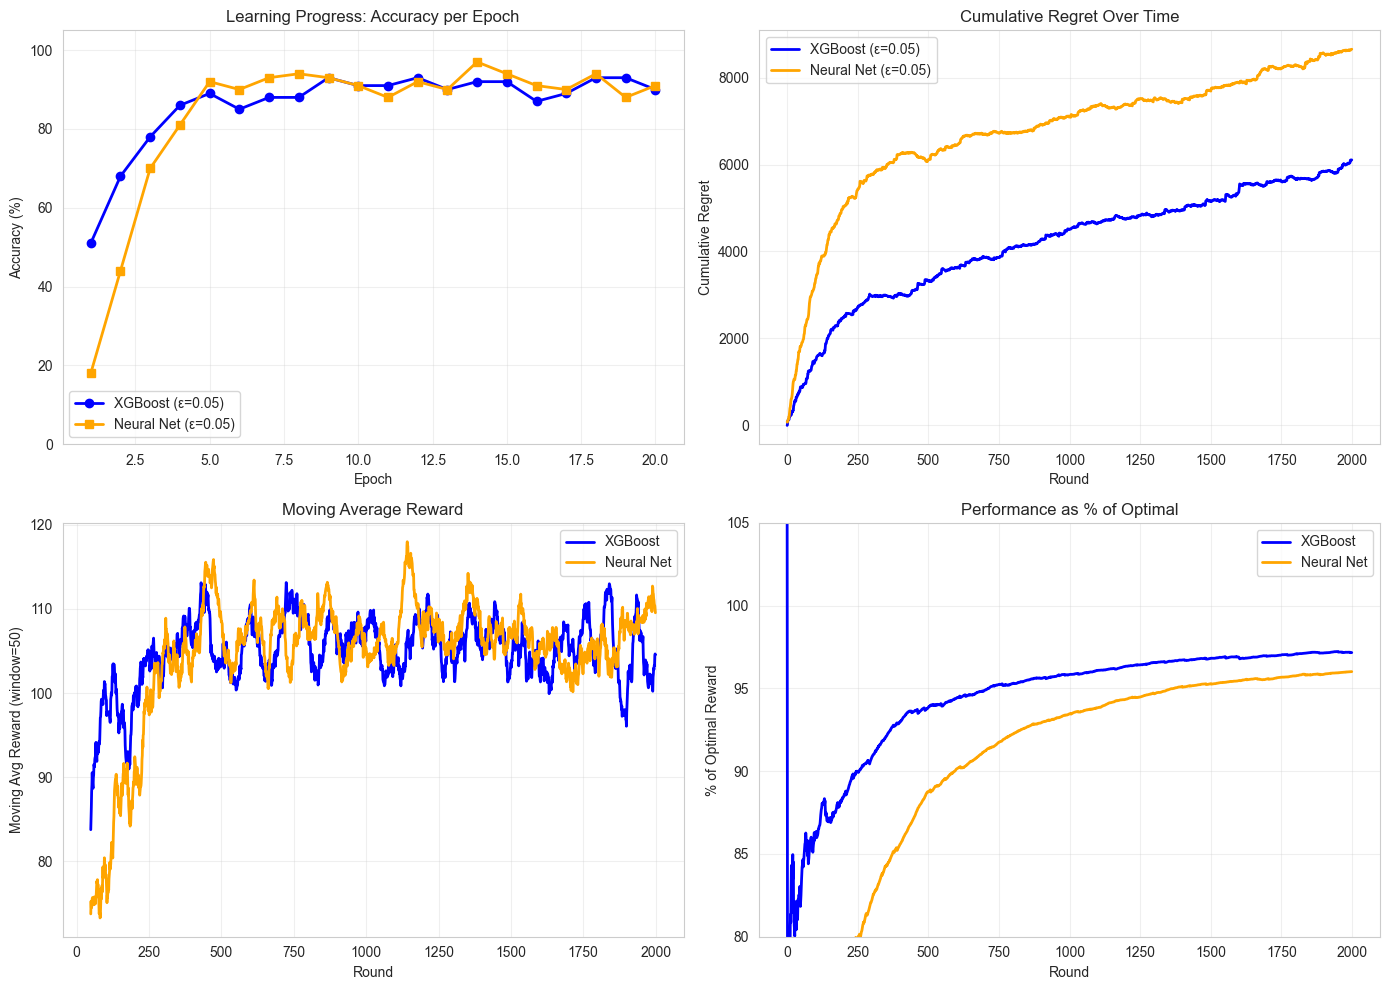

In [13]:
# Compare XGBoost vs Neural Network
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

n_epochs = 20

# Plot 1: Accuracy Learning Curves
xgb_accuracies = [final_xgb_history['epoch_accuracy'][e * CLASS_SIZE] for e in range(n_epochs)]
nn_accuracies = [final_nn_history['epoch_accuracy'][e * CLASS_SIZE] for e in range(n_epochs)]
epochs = list(range(1, n_epochs + 1))

axes[0, 0].plot(epochs, xgb_accuracies, label=f'XGBoost (ε={best_xgb_eps})', linewidth=2, marker='o', color='blue')
axes[0, 0].plot(epochs, nn_accuracies, label=f'Neural Net (ε={best_nn_eps})', linewidth=2, marker='s', color='orange')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Learning Progress: Accuracy per Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim([0, 105])

# Plot 2: Cumulative Regret
axes[0, 1].plot(final_xgb_history['round'], final_xgb_history['regret'], 
                label=f'XGBoost (ε={best_xgb_eps})', linewidth=2, color='blue')
axes[0, 1].plot(final_nn_history['round'], final_nn_history['regret'], 
                label=f'Neural Net (ε={best_nn_eps})', linewidth=2, color='orange')
axes[0, 1].set_xlabel('Round')
axes[0, 1].set_ylabel('Cumulative Regret')
axes[0, 1].set_title('Cumulative Regret Over Time')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Moving Average Reward
window = 50
xgb_ma = pd.Series(final_xgb_history['reward']).rolling(window=window).mean()
nn_ma = pd.Series(final_nn_history['reward']).rolling(window=window).mean()

axes[1, 0].plot(final_xgb_history['round'], xgb_ma, label=f'XGBoost', linewidth=2, color='blue')
axes[1, 0].plot(final_nn_history['round'], nn_ma, label=f'Neural Net', linewidth=2, color='orange')
axes[1, 0].set_xlabel('Round')
axes[1, 0].set_ylabel(f'Moving Avg Reward (window={window})')
axes[1, 0].set_title('Moving Average Reward')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: % of Optimal Reward
xgb_pct = [final_xgb_history['cumulative_reward'][i] / final_xgb_history['cumulative_optimal_reward'][i] * 100 
           for i in range(len(final_xgb_history['round']))]
nn_pct = [final_nn_history['cumulative_reward'][i] / final_nn_history['cumulative_optimal_reward'][i] * 100 
          for i in range(len(final_nn_history['round']))]

axes[1, 1].plot(final_xgb_history['round'], xgb_pct, label=f'XGBoost', linewidth=2, color='blue')
axes[1, 1].plot(final_nn_history['round'], nn_pct, label=f'Neural Net', linewidth=2, color='orange')
axes[1, 1].set_xlabel('Round')
axes[1, 1].set_ylabel('% of Optimal Reward')
axes[1, 1].set_title('Performance as % of Optimal')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([80, 105])

plt.tight_layout()
plt.show()

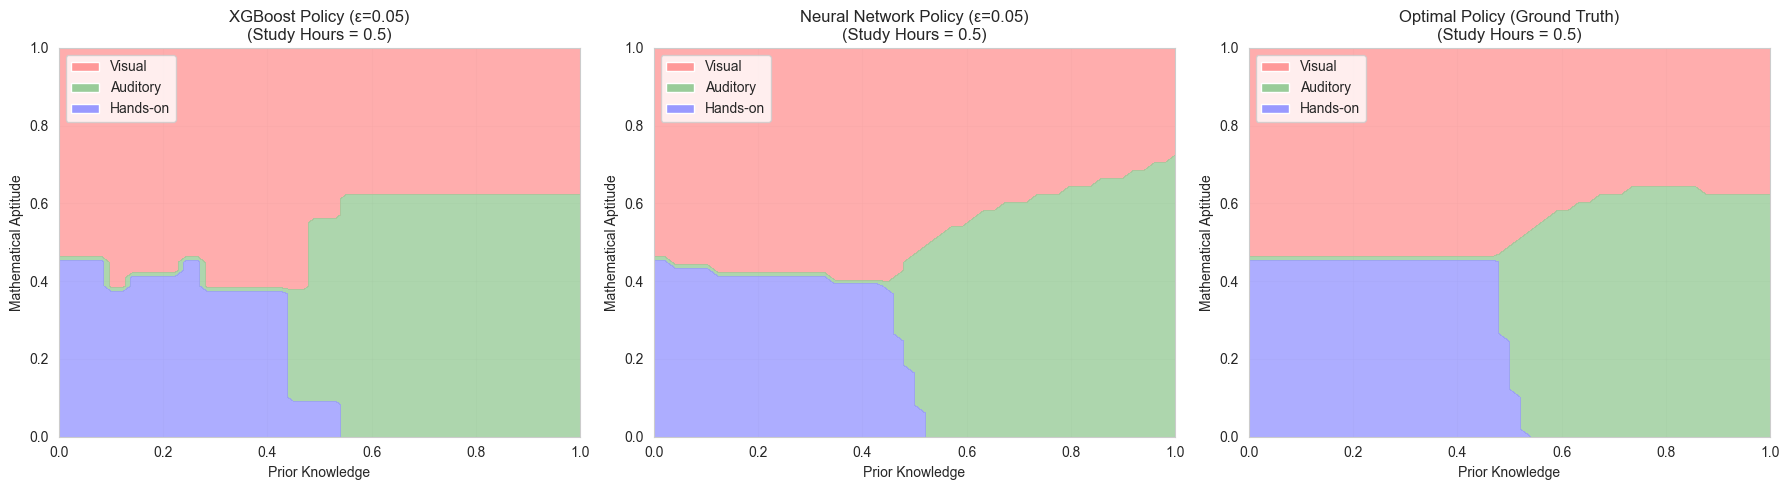


Decision boundary accuracy compared to optimal:
  XGBoost: 94.9%
  Neural Network: 95.9%


In [14]:
# Visualize learned decision boundaries
n_points = 50
prior_knowledge_range = np.linspace(0, 1, n_points)
aptitude_range = np.linspace(0, 1, n_points)
PK, AP = np.meshgrid(prior_knowledge_range, aptitude_range)

# Get predictions from each model
xgb_predictions = np.zeros_like(PK)
nn_predictions = np.zeros_like(PK)
optimal_predictions = np.zeros_like(PK)

for i in range(n_points):
    for j in range(n_points):
        context = np.array([PK[i, j], 0.5, AP[i, j]])  # Fixed study hours = 0.5
        xgb_predictions[i, j] = final_xgb.predict_best_arm(context)
        nn_predictions[i, j] = final_nn.predict_best_arm(context)
        optimal_predictions[i, j] = ground_truth.get_optimal_arm(context)

# Plot decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

legend_elements = [Patch(facecolor='#ff9999', label='Visual'),
                   Patch(facecolor='#99cc99', label='Auditory'),
                   Patch(facecolor='#9999ff', label='Hands-on')]

# XGBoost
axes[0].contourf(PK, AP, xgb_predictions, levels=[-0.5, 0.5, 1.5, 2.5], 
                 colors=['#ff9999', '#99cc99', '#9999ff'], alpha=0.8)
axes[0].set_xlabel('Prior Knowledge')
axes[0].set_ylabel('Mathematical Aptitude')
axes[0].set_title(f'XGBoost Policy (ε={best_xgb_eps})\n(Study Hours = 0.5)')
axes[0].legend(handles=legend_elements, loc='upper left')
axes[0].grid(True, alpha=0.3)

# Neural Network
axes[1].contourf(PK, AP, nn_predictions, levels=[-0.5, 0.5, 1.5, 2.5], 
                 colors=['#ff9999', '#99cc99', '#9999ff'], alpha=0.8)
axes[1].set_xlabel('Prior Knowledge')
axes[1].set_ylabel('Mathematical Aptitude')
axes[1].set_title(f'Neural Network Policy (ε={best_nn_eps})\n(Study Hours = 0.5)')
axes[1].legend(handles=legend_elements, loc='upper left')
axes[1].grid(True, alpha=0.3)

# Ground Truth
axes[2].contourf(PK, AP, optimal_predictions, levels=[-0.5, 0.5, 1.5, 2.5], 
                 colors=['#ff9999', '#99cc99', '#9999ff'], alpha=0.8)
axes[2].set_xlabel('Prior Knowledge')
axes[2].set_ylabel('Mathematical Aptitude')
axes[2].set_title('Optimal Policy (Ground Truth)\n(Study Hours = 0.5)')
axes[2].legend(handles=legend_elements, loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate decision accuracy
xgb_accuracy = np.mean(xgb_predictions == optimal_predictions) * 100
nn_accuracy = np.mean(nn_predictions == optimal_predictions) * 100
print(f"\nDecision boundary accuracy compared to optimal:")
print(f"  XGBoost: {xgb_accuracy:.1f}%")
print(f"  Neural Network: {nn_accuracy:.1f}%")

In [15]:
# Summary statistics comparison
print("=" * 80)
print("FINAL COMPARISON: XGBoost vs Neural Network")
print("=" * 80)

# Extract final metrics
xgb_final_acc = final_xgb_history['epoch_accuracy'][(n_epochs-1) * CLASS_SIZE]
nn_final_acc = final_nn_history['epoch_accuracy'][(n_epochs-1) * CLASS_SIZE]

xgb_final_regret = final_xgb_history['regret'][-1]
nn_final_regret = final_nn_history['regret'][-1]

xgb_pct_optimal = final_xgb_history['cumulative_reward'][-1] / final_xgb_history['cumulative_optimal_reward'][-1] * 100
nn_pct_optimal = final_nn_history['cumulative_reward'][-1] / final_nn_history['cumulative_optimal_reward'][-1] * 100

print(f"\n{'Metric':<30} | {'XGBoost':^15} | {'Neural Net':^15} | {'Winner':^15}")
print("-" * 80)

# Final Accuracy
winner = "XGBoost" if xgb_final_acc > nn_final_acc else "Neural Net" if nn_final_acc > xgb_final_acc else "Tie"
print(f"{'Final Epoch Accuracy (%)':<30} | {xgb_final_acc:^15.1f} | {nn_final_acc:^15.1f} | {winner:^15}")

# Final Regret
winner = "XGBoost" if xgb_final_regret < nn_final_regret else "Neural Net" if nn_final_regret < xgb_final_regret else "Tie"
print(f"{'Cumulative Regret':<30} | {xgb_final_regret:^15.2f} | {nn_final_regret:^15.2f} | {winner:^15}")

# % of Optimal
winner = "XGBoost" if xgb_pct_optimal > nn_pct_optimal else "Neural Net" if nn_pct_optimal > xgb_pct_optimal else "Tie"
print(f"{'% of Optimal Reward':<30} | {xgb_pct_optimal:^15.2f} | {nn_pct_optimal:^15.2f} | {winner:^15}")

# Decision Boundary Accuracy
winner = "XGBoost" if xgb_accuracy > nn_accuracy else "Neural Net" if nn_accuracy > xgb_accuracy else "Tie"
print(f"{'Decision Boundary Accuracy (%)':<30} | {xgb_accuracy:^15.1f} | {nn_accuracy:^15.1f} | {winner:^15}")

# Memory Usage
xgb_samples = len(final_xgb.X_train)
nn_buffer = len(final_nn.replay_buffer)
winner = "Neural Net"  # Always wins on memory
print(f"{'Samples Stored':<30} | {xgb_samples:^15} | {nn_buffer:^15} | {winner:^15}")

print("\n" + "=" * 80)
print("LEARNING APPROACH COMPARISON")
print("=" * 80)
print(f"\nXGBoost (Batch Learning):")
print(f"  - Stores all {xgb_samples} training samples")
print(f"  - Retrains on entire dataset after each observation")
print(f"  - Training complexity: O(n²) cumulative")

print(f"\nNeural Network (Online Learning):")
print(f"  - Stores only {nn_buffer} samples in replay buffer")
print(f"  - Updates with mini-batch gradient descent")
print(f"  - Training complexity: O(1) per observation")
print(f"  - Memory reduction: {(1 - nn_buffer/xgb_samples)*100:.1f}%")

FINAL COMPARISON: XGBoost vs Neural Network

Metric                         |     XGBoost     |   Neural Net    |     Winner     
--------------------------------------------------------------------------------
Final Epoch Accuracy (%)       |      90.0       |      91.0       |   Neural Net   
Cumulative Regret              |     6106.67     |     8654.59     |     XGBoost    
% of Optimal Reward            |      97.17      |      96.02      |     XGBoost    
Decision Boundary Accuracy (%) |      94.9       |      95.9       |   Neural Net   
Samples Stored                 |      2000       |       500       |   Neural Net   

LEARNING APPROACH COMPARISON

XGBoost (Batch Learning):
  - Stores all 2000 training samples
  - Retrains on entire dataset after each observation
  - Training complexity: O(n²) cumulative

Neural Network (Online Learning):
  - Stores only 500 samples in replay buffer
  - Updates with mini-batch gradient descent
  - Training complexity: O(1) per observation
  -

## 6. Conclusion

### Key Findings

**XGBoost (Batch Learning):**
- Retrains on all historical data after each observation
- Generally achieves good accuracy and low regret
- Memory usage grows linearly with data (stores all samples)
- Training time increases as O(n²) cumulative complexity
- Better suited for offline learning or when computational resources allow batch retraining

**Neural Network (Online Learning):**
- Updates incrementally using mini-batch gradient descent
- Uses experience replay buffer with fixed memory footprint
- Training complexity is O(1) per observation
- May require more careful hyperparameter tuning (learning rate, architecture)
- Better suited for streaming data or resource-constrained environments

### When to Use Each Approach

| Scenario | Recommended Approach |
|----------|---------------------|
| Small to medium dataset | XGBoost (batch) |
| Streaming/real-time data | Neural Network (online) |
| Memory-constrained environment | Neural Network (online) |
| Interpretability needed | XGBoost (feature importance) |
| Complex non-linear patterns | Either (both handle well) |
| Concept drift expected | Neural Network (forgets old data) |

### Trade-offs

1. **Sample Efficiency vs Memory**: XGBoost uses all data for better sample efficiency, but requires storing everything
2. **Accuracy vs Speed**: Batch retraining may be more accurate but slower as data grows
3. **Stability vs Adaptability**: Neural networks with replay buffer balance stability with ability to adapt to new patterns